# Access the analysis ready seasonal monthly single levels data

This notebook provides an example of how to open the seasonal-monthly-single-levels Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-043/arco/seasonal_monthly_single_levels/ecmwf-51/geoChunked.zarr"

# Time-chunked data (optimised for map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-043/arco/seasonal_monthly_single_levels/ecmwf-51/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 475GB
Dimensions:     (time: 544, time_step: 6, member: 51, latitude: 180,
                 longitude: 360)
Coordinates:
  * time        (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-04-01
  * time_step   (time_step) int32 24B 1 2 3 4 5 6
  * member      (member) int32 204B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
    start_time  (time, member) datetime64[ns] 222kB dask.array<chunksize=(128, 1), meta=np.ndarray>
  * latitude    (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude   (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    d2m         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    mn2t24      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    msdsrf      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    msl         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    mx2t24      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    siconc      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    sst         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    t2m         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    tprate      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    u10         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    v10         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    history:      2025-11-07T09:49 GRIB to CDM+CF via cfgrib-0.9.10.4/ecCodes...
    institution:  European Centre for Medium-Range Weather Forecasts

Extract a point and plot a time-series using earthkit-plots.

In [3]:
from earthkit import plots as ekp
from earthkit import transforms as ekt

# Select variable to plot
variable_name = "d2m"
subset = ds[variable_name].sel(
    latitude=51.5, longitude=-0.1, method="nearest"
).sel(time="2000").compute()

plot_data_mean = ekt.ensemble.mean(subset)
plot_data_std = ekt.ensemble.std(subset)

# Calculate the valid time by adding the time and time_step together, converting time_step to a timedelta of months,
# so we can add them together to get the actual time of the forecast.
plot_data_mean["valid_time"] = plot_data_mean["time"] + plot_data_mean["time_step"].astype("timedelta64[M]")
plot_data_std["valid_time"] = plot_data_std["time"] + plot_data_std["time_step"].astype("timedelta64[M]")

plot_data_std

<xarray.DataArray 'd2m' (time: 12, time_step: 6)> Size: 288B
array([[1.1007484, 1.6250689, 1.2628654, 1.547307 , 1.1941029, 1.2110184],
       [0.9507599, 1.5802124, 1.1984694, 1.3604546, 1.7767406, 0.5724305],
       [1.0001032, 1.3669012, 1.1256063, 1.0911436, 0.9135776, 1.3061932],
       [1.0000073, 1.1559193, 1.0040774, 1.2453518, 1.017305 , 1.1563157],
       [0.936417 , 1.3145757, 1.2026634, 1.059141 , 1.644459 , 1.493266 ],
       [1.0803103, 0.8639851, 1.2176958, 1.1463773, 1.7920654, 1.4526473],
       [0.780133 , 1.1329027, 1.2439891, 1.5981992, 1.4990076, 2.295272 ],
       [0.6806135, 1.0972748, 1.2329394, 1.2362516, 1.279222 , 2.0263925],
       [0.8066176, 1.260044 , 1.4156653, 1.774057 , 2.2668405, 1.8005551],
       [1.0164953, 1.6558936, 1.9804673, 2.0278995, 2.0020144, 1.435941 ],
       [1.0104653, 1.2257411, 1.9199579, 2.1454911, 2.0640645, 1.4175841],
       [1.7050605, 1.3457096, 1.9122144, 1.3093544, 1.3536352, 1.4015702]],
      dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 96B 2000-01-01 2000-02-01 ... 2000-12-01
  * time_step   (time_step) int32 24B 1 2 3 4 5 6
    valid_time  (time, time_step) datetime64[ns] 576B 2000-02-01 ... 2001-05-31
    latitude    float64 8B 51.5
    longitude   float64 8B -0.5
Attributes:
    long_name:      2 metre dewpoint temperature
    standard_name:  unknown
    units:          K

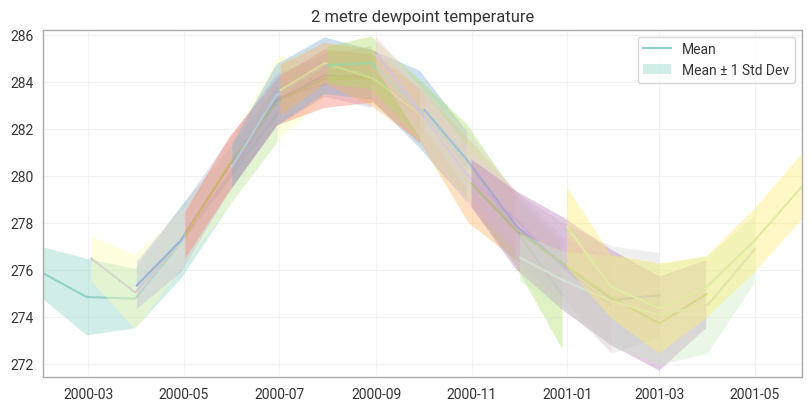

In [4]:
chart = ekp.TimeSeries()

for i, time in enumerate(plot_data_mean.time):
    if i == 0:
        m_kwargs = {"label": "Mean"}
        s_kwargs = {"label": "Mean ± 1 Std Dev"}
    else:
        m_kwargs = {}
        s_kwargs = {}
    chart.line(plot_data_mean.sel(time=time), x="valid_time", **m_kwargs)
    chart.envelope(
        (plot_data_mean-plot_data_std).sel(time=time),
        (plot_data_mean+plot_data_std).sel(time=time),
        x="valid_time",
        **s_kwargs
    )

chart.title("{long_name}")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [5]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-043/arco/seasonal_monthly_single_levels/ecmwf-51/geoChunked.zarr"

# Time-chunked data (optimised for map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-043/arco/seasonal_monthly_single_levels/ecmwf-51/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 475GB
Dimensions:     (time: 544, time_step: 6, member: 51, latitude: 180,
                 longitude: 360)
Coordinates:
  * time        (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-04-01
  * time_step   (time_step) int32 24B 1 2 3 4 5 6
  * member      (member) int32 204B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
    start_time  (time, member) datetime64[ns] 222kB dask.array<chunksize=(128, 1), meta=np.ndarray>
  * latitude    (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude   (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    d2m         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    mn2t24      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    msdsrf      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    msl         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    mx2t24      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    siconc      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    sst         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    t2m         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    tprate      (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    u10         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
    v10         (time, time_step, member, latitude, longitude) float32 43GB dask.array<chunksize=(128, 1, 1, 64, 128), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    history:      2025-11-07T09:49 GRIB to CDM+CF via cfgrib-0.9.10.4/ecCodes...
    institution:  European Centre for Medium-Range Weather Forecasts

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.